In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def read_xy_file(filename):
    with open(filename, 'r') as file:
        lines = file.readlines()
    
    sample_name = lines[0].strip()  # First line is the sample name
    parameters = lines[1].strip()   # Second line contains parameters (not used in plot)
    
    # Read x, y data from the third line onward
    x_data, y_data = [], []
    for line in lines[2:]:
        try:
            x, y = map(float, line.split()[:2])
            x_data.append(x)
            y_data.append(y)
        except ValueError:
            continue  # Skip any malformed lines
    
    return sample_name, x_data, y_data

def plot_xy_data(filename):
    sample_name, x_data, y_data = read_xy_file(filename)
    
    # plt.figure(figsize=(8, 6))
    plt.plot(x_data, y_data, linestyle='-', label=sample_name, alpha=0.6)
    # plt.plot(x_data, y_data, marker='o', linestyle='-', color='b', markersize=3, label=sample_name)
    # plt.xlabel('X-Axis')
    # plt.ylabel('Y-Axis')
    # plt.title(f'Scan Data: {sample_name}')
    # plt.legend()
    # plt.grid(True)
    # plt.show()

# Pseudo-Voigt function
def pseudo_voigt(x, A, x0, sigma, gamma, eta):
    gaussian = A * np.exp(-(x - x0)**2 / (2 * sigma**2))
    lorentzian = A * gamma**2 / ((x - x0)**2 + gamma**2)
    return eta * lorentzian + (1 - eta) * gaussian


def plot_fit_data(filename, x_min=35, x_max=41):
    sample_name, x_data, y_data = read_xy_file(filename)
    
    # Select data around the peak
    x_data = np.array(x_data)
    y_data = np.array(y_data)
    mask = (x_data >= x_min) & (x_data <= x_max)
    x_fit = x_data[mask]
    y_fit = y_data[mask]

    # Initial guess and bounds
    p0 = [np.max(y_fit), 38.1, 0.1, 0.1, 0.5]
    bounds = ([0, x_min, 0, 0, 0], [np.inf, x_max, 1, 1, 1])

    # Fit
    popt, pcov = curve_fit(pseudo_voigt, x_fit, y_fit, p0=p0, bounds=bounds)
    x_dense = np.linspace(x_fit.min(), x_fit.max(), 10000)
    fit_y = pseudo_voigt(x_dense, *popt)

    half_max = np.max(fit_y) / 2
    # find indices where curve crosses half max
    indices = np.where(fit_y >= half_max)[0]
    fwhm = x_dense[indices[-1]] - x_dense[indices[0]]
    
    perr = np.sqrt(np.diag(pcov))

    # Plot fit
    plt.plot(x_dense, fit_y, '--', label=f'{sample_name} fit')

    return popt, perr, fwhm  # [A, x0, sigma, gamma, eta]


# def plot_fit_data_2(filename):
#     sample_name, x_data, y_data = read_xy_file(filename)
    
#     # Find background
#     x_data = np.array(x_data)
#     y_data = np.array(y_data)
#     mask = (x_data >= 33.5) & (x_data <= 35) #region with no peaks
#     y_bg_level = max(np.mean(y_data[mask]),1)

#     mask_2 = (x_data >= 33.5) # region excluding Si 002 peak
#     x_peak = x_data[mask_2]
#     y_peak = y_data[mask_2]

#     mask_3=(y_peak>y_bg_level)
#     x_fit = x_peak[mask_3]
#     y_fit = y_peak[mask_3]

#     # Initial guess and bounds
#     p0 = [np.max(y_fit), 38, 0.1, 0.1, 0.5]
#     bounds = ([0, x_fit.min(), 0, 0, 0], [np.inf, x_fit.max(), 1, 1, 1])

#     # Fit
#     popt, pcov = curve_fit(pseudo_voigt, x_fit, y_fit, p0=p0, bounds=bounds)
#     fit_y = pseudo_voigt(x_fit, *popt)
    
#     perr = np.sqrt(np.diag(pcov))

#     # Plot fit
#     plt.plot(x_fit, fit_y, '--', label=f'{sample_name} fit')

#     return popt, perr  # [A, x0, sigma, gamma, eta]

## Fit all data
Note: JT4 data was corrupted when taking data for the second time

JT1 peak (20250421) center (x0): 38.03579, err = 0.00128, fwhm = 0.44764
JT1 peak (20250611) center (x0): 38.03590, err = 0.00068, fwhm = 0.51665


/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_37404/348053894.py:26: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,50000)


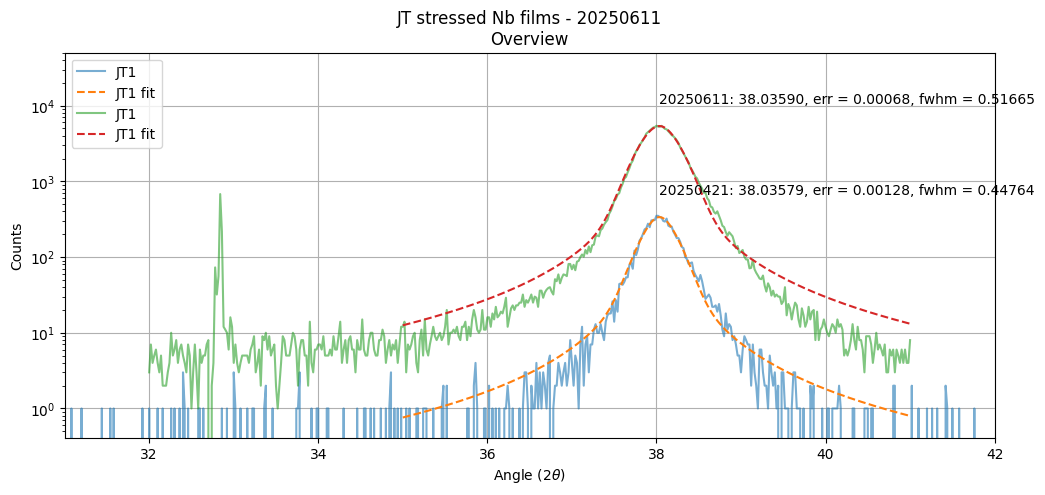

JT2 peak (20250421) center (x0): 38.22767, err = 0.00296, fwhm = 0.51065
JT2 peak (20250611) center (x0): 38.22585, err = 0.00073, fwhm = 0.57486


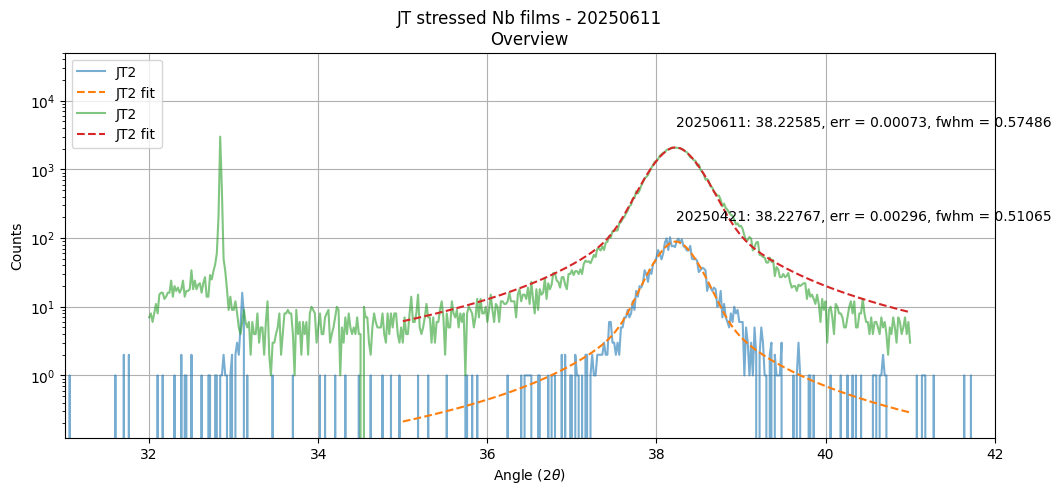

JT3 peak (20250421) center (x0): 38.13615, err = 0.00226, fwhm = 0.49985
JT3 peak (20250611) center (x0): 38.16354, err = 0.00097, fwhm = 0.58086


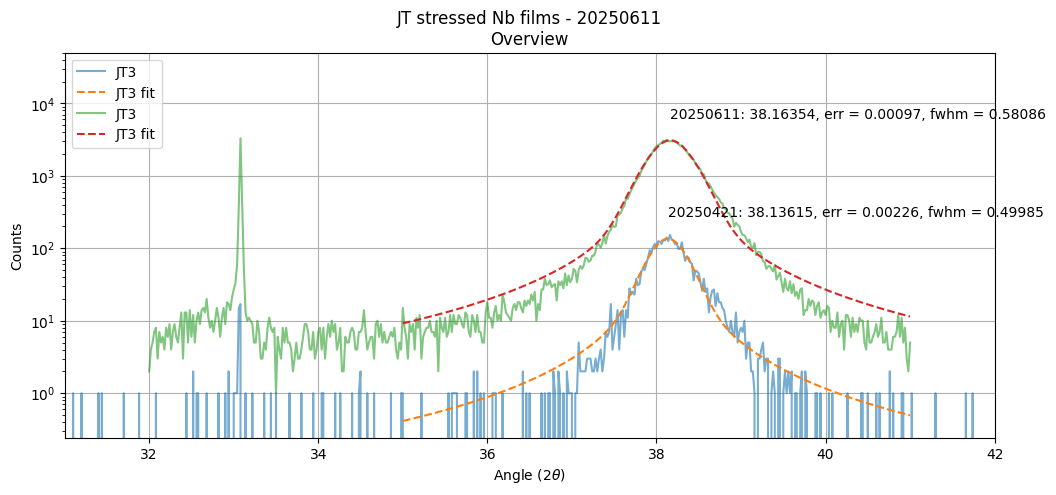

JT4 peak (20250421) center (x0): 38.41943, err = 0.00475, fwhm = 0.50105


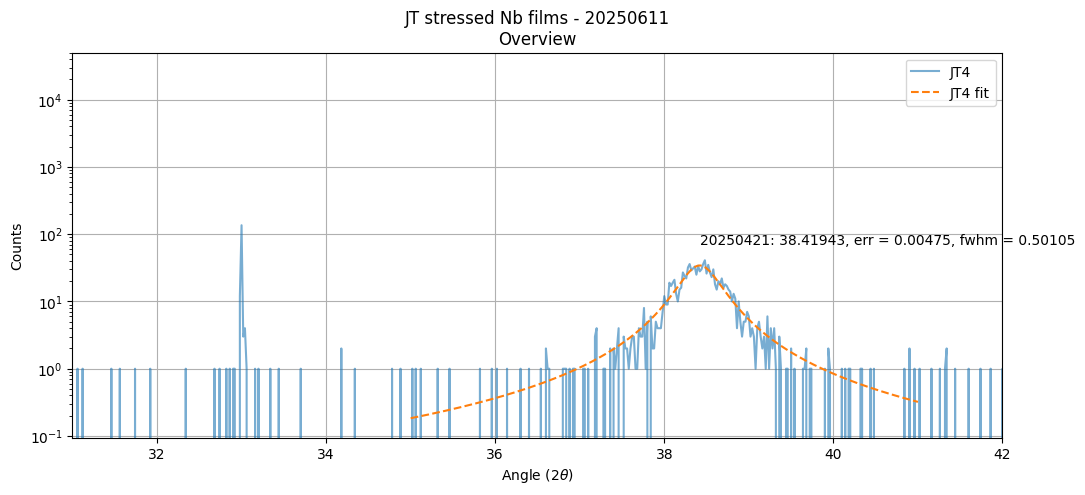

JT5 peak (20250421) center (x0): 38.24877, err = 0.00422, fwhm = 0.59886
JT5 peak (20250611) center (x0): 38.26104, err = 0.00086, fwhm = 0.60306


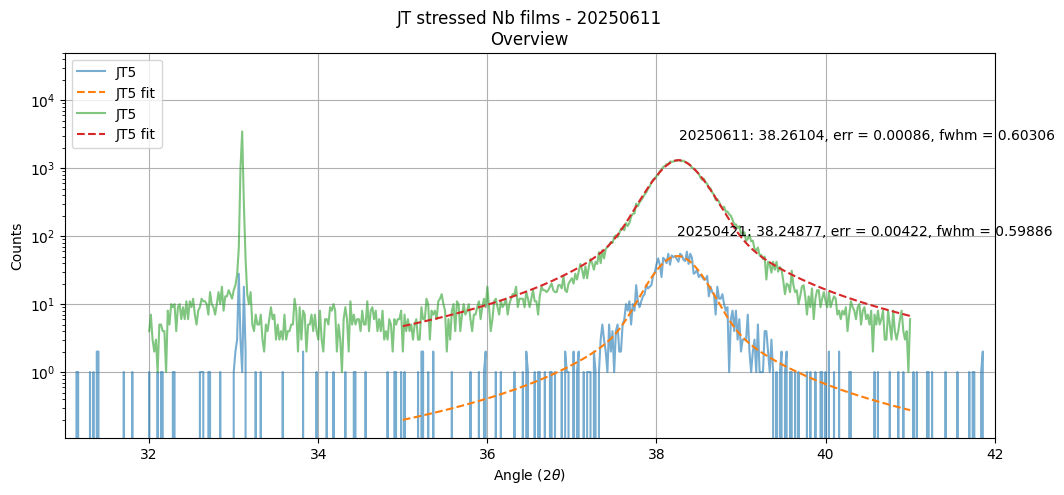

JT6 peak (20250421) center (x0): 38.26100, err = 0.00189, fwhm = 0.48425
JT6 peak (20250611) center (x0): 38.27461, err = 0.00058, fwhm = 0.56166


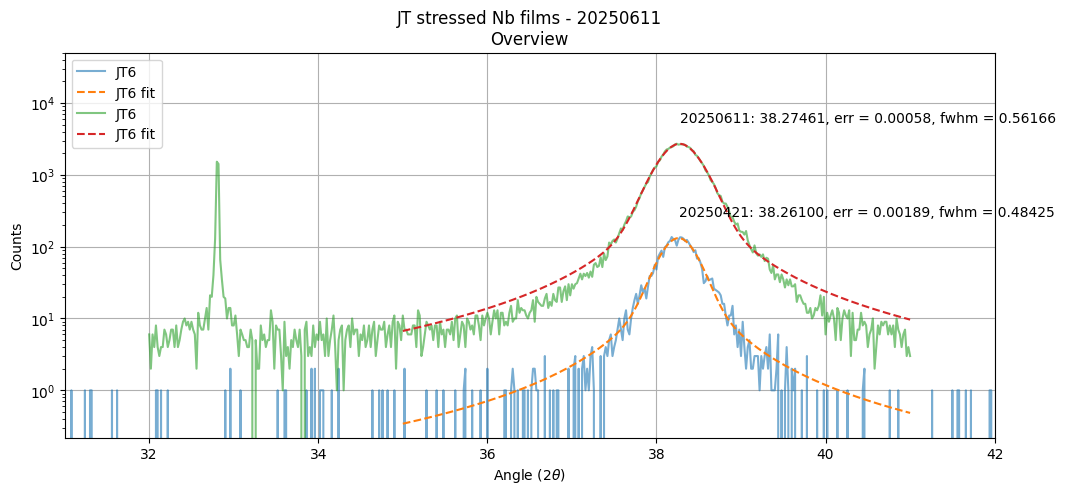

JT7 peak (20250421) center (x0): 38.26570, err = 0.00104, fwhm = 0.40504
JT7 peak (20250611) center (x0): 38.26719, err = 0.00039, fwhm = 0.49505


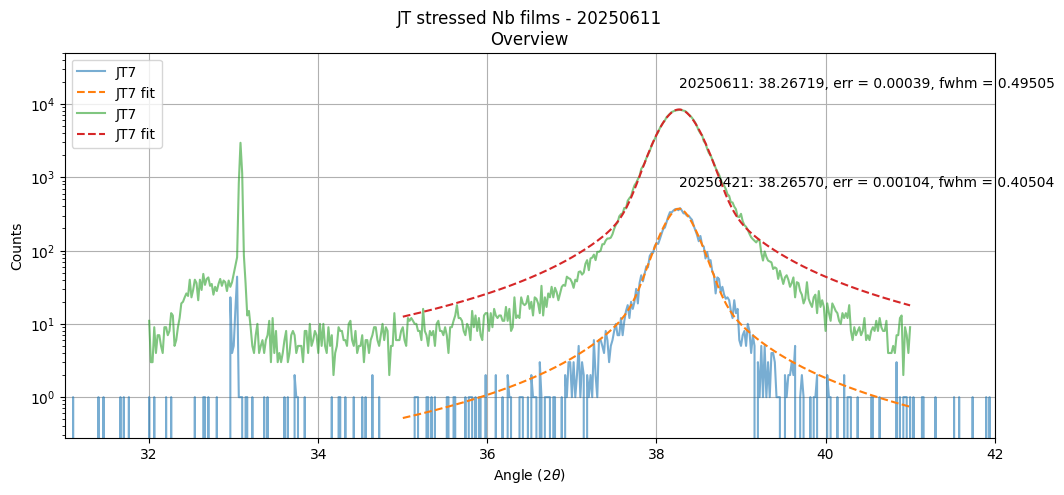

JT8 peak (20250421) center (x0): 38.16273, err = 0.00223, fwhm = 0.52865
JT8 peak (20250611) center (x0): 38.16516, err = 0.00094, fwhm = 0.58866


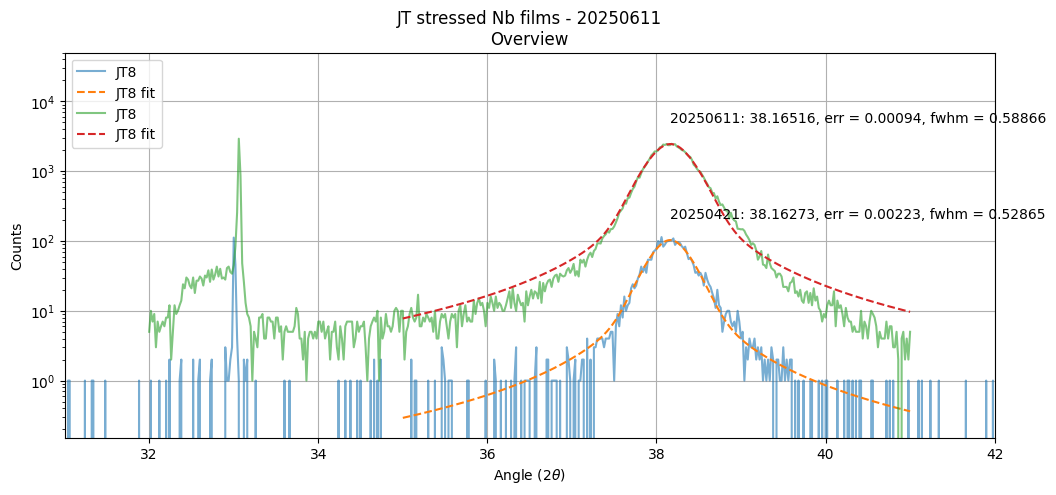

JT9 peak (20250421) center (x0): 38.10819, err = 0.00126, fwhm = 0.42664
JT9 peak (20250611) center (x0): 38.11518, err = 0.00053, fwhm = 0.52265


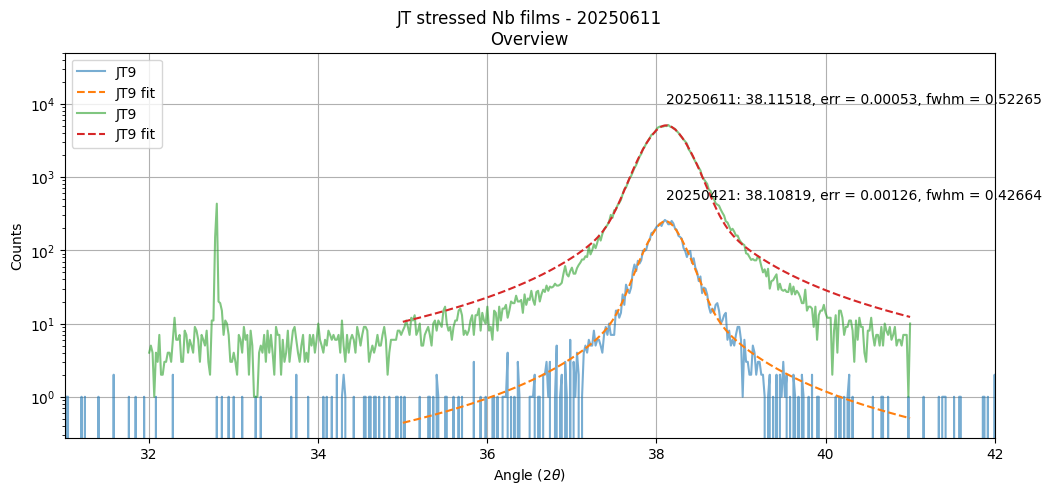

JT10 peak (20250421) center (x0): 38.20222, err = 0.00076, fwhm = 0.38704
JT10 peak (20250611) center (x0): 38.20624, err = 0.00036, fwhm = 0.47285


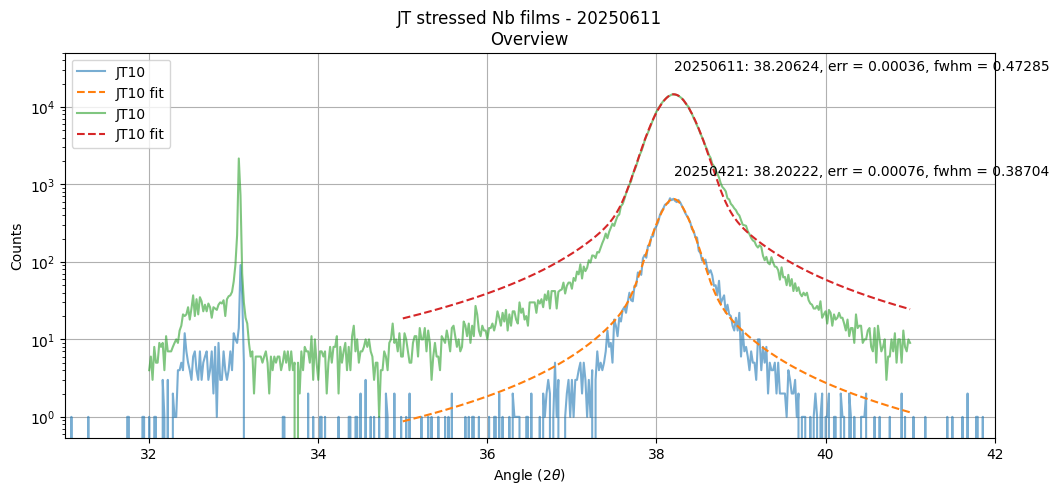

In [26]:
date = "20250611"

for i in range(10):
    plt.figure(figsize=(12, 5))
    plt.title(f"JT stressed Nb films - {date}\nOverview")

    plot_xy_data(f'JT{i+1}_Theta_2-Theta.xy')
    popt, perr, fwhm = plot_fit_data(f'JT{i+1}_Theta_2-Theta.xy')
    print(f"JT{i+1} peak (20250421) center (x0): {popt[1]:.5f}, err = {perr[1]:.5f}, fwhm = {fwhm:.5f}")
    plt.text(popt[1], popt[0]*2, f"20250421: {popt[1]:.5f}, err = {perr[1]:.5f}, fwhm = {fwhm:.5f}",rotation = 0)
    if i != 3:
        plot_xy_data(f'20250611_JT{i+1}_Theta_2-Theta.xy')
        popt, perr, fwhm = plot_fit_data(f'20250611_JT{i+1}_Theta_2-Theta.xy')
        print(f"JT{i+1} peak (20250611) center (x0): {popt[1]:.5f}, err = {perr[1]:.5f}, fwhm = {fwhm:.5f}")
        plt.text(popt[1], popt[0]*2, f"20250611: {popt[1]:.5f}, err = {perr[1]:.5f}, fwhm = {fwhm:.5f}",rotation = 0)

    plt.xlabel(r'Angle (2$\theta$)')
    # plt.text(33.2, 320, r"$\beta$-Ta 002",rotation = 90)
    # plt.text(35.6, 30, r"$\beta$-Ta 410",rotation = 90)
    # plt.text(37.9, 2400, r"$\alpha$-Ta 110",rotation = 90)
    # plt.text(68.8, 95, r"Si 004",rotation = 90)
    # plt.text(70.2, 90, r"$\beta$-Ta 004",rotation = 90)
    # plt.text(81.6, 120, r"$\alpha$-Ta 220",rotation = 90)
    plt.ylabel('Counts')
    plt.yscale('log')
    plt.ylim(0,50000)
    plt.xlim(31,42)
    plt.legend()
    plt.grid(True)
    plt.savefig(f'XRD_data_JT{i+1}_re.png',format='png')
    plt.show()



### Error approximation

In [52]:
#Error approx through repeatability
peak_Apr = [38.03579, 38.22767, 38.13615, 38.24877, 38.26100, 38.26570, 38.16273, 38.10819, 38.20222]
peak_Jun = [38.03590, 38.22585, 38.16354, 38.26104, 38.27461, 38.26719, 38.16516, 38.11518, 38.20624]
differences = np.array(peak_Apr) - np.array(peak_Jun)
exp_error = np.std(differences)
exp_error

np.float64(0.008636188431089308)

In [ ]:
#Error approx through resolution
#idt this is real and is double counting since any resolution error will be reflected in the exp_error from before, but heres the resolution step
res_uncertainty = 0.02 / np.sqrt(3) #for rectangular distribtion
res_uncertainty

np.float64(0.011547005383792516)

JT1 peak (20250421) center (x0): 69.19826, err = 0.00039, fwhm = 0.04800
[1.68404024e+05 6.91982609e+01 2.25021938e-02 1.78334125e-02
 2.74508540e-01]


/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_37404/4154903664.py:78: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,5000000)


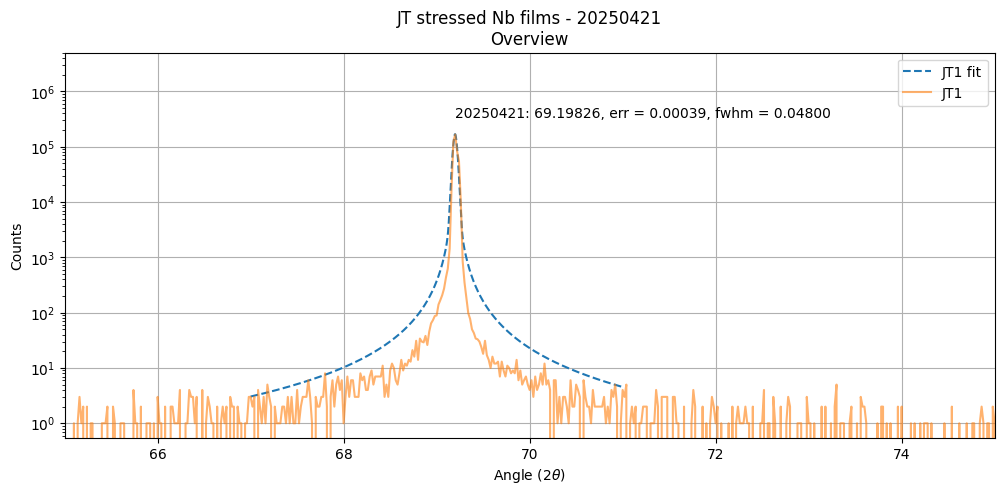

JT2 peak (20250421) center (x0): 69.27726, err = 0.00042, fwhm = 0.04800
[1.13895320e+04 6.92772627e+01 1.91880432e-02 3.46778601e-02
 2.23297609e-01]


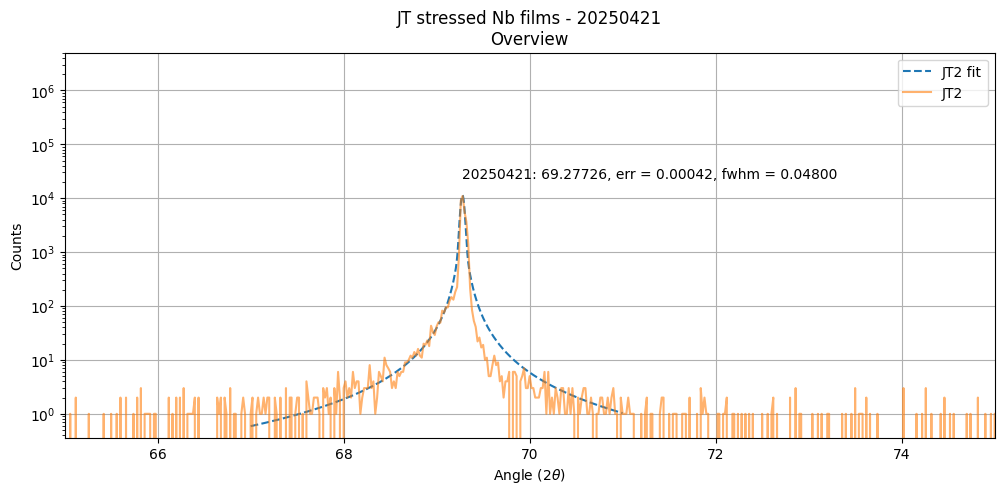

JT3 peak (20250421) center (x0): 69.27114, err = 0.00043, fwhm = 0.04560
[1.75140287e+04 6.92711375e+01 1.80633276e-02 3.31268921e-02
 2.46243090e-01]


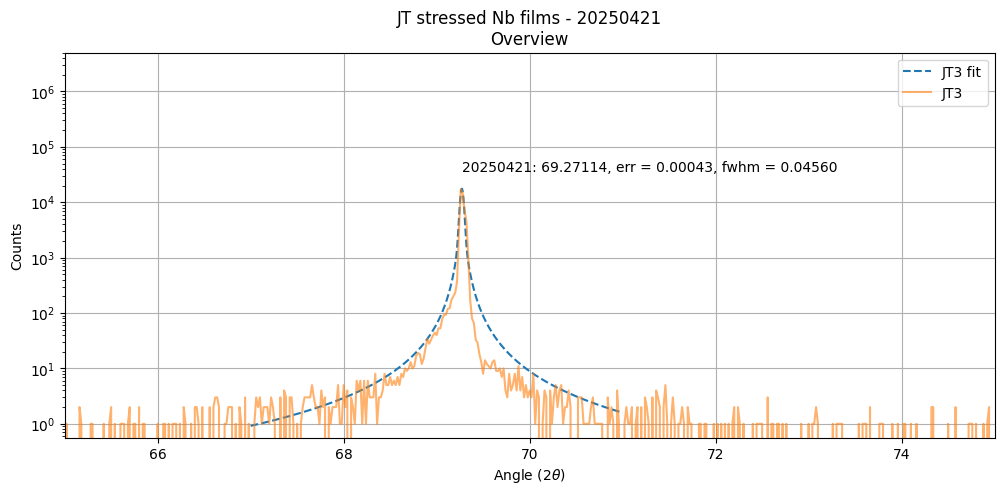

JT4 peak (20250421) center (x0): 69.18862, err = 0.00029, fwhm = 0.03120
[1.52385208e+05 6.91886223e+01 1.77312276e-05 1.70713573e-02
 9.29196712e-01]


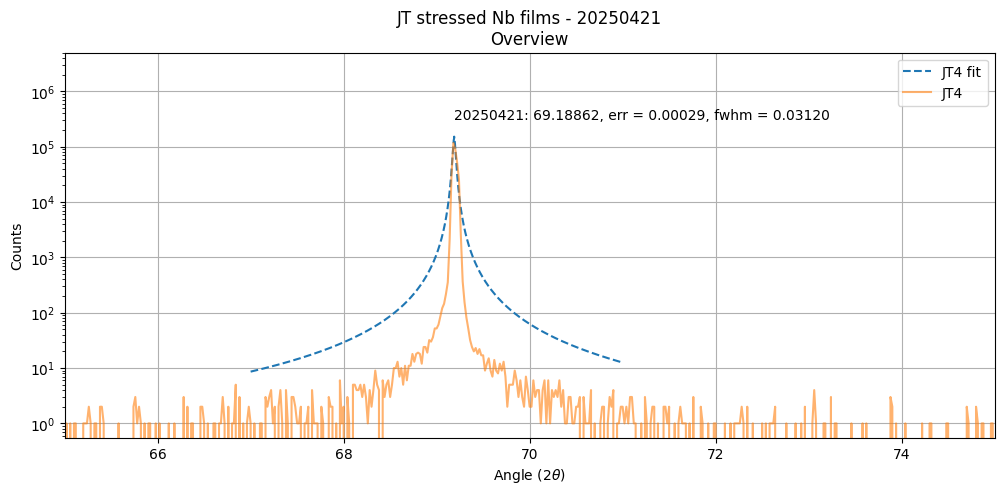

JT5 peak (20250421) center (x0): 69.25427, err = 0.00051, fwhm = 0.05281
[3.59839350e+04 6.92542667e+01 2.20332711e-02 4.04605140e-02
 9.44772384e-02]


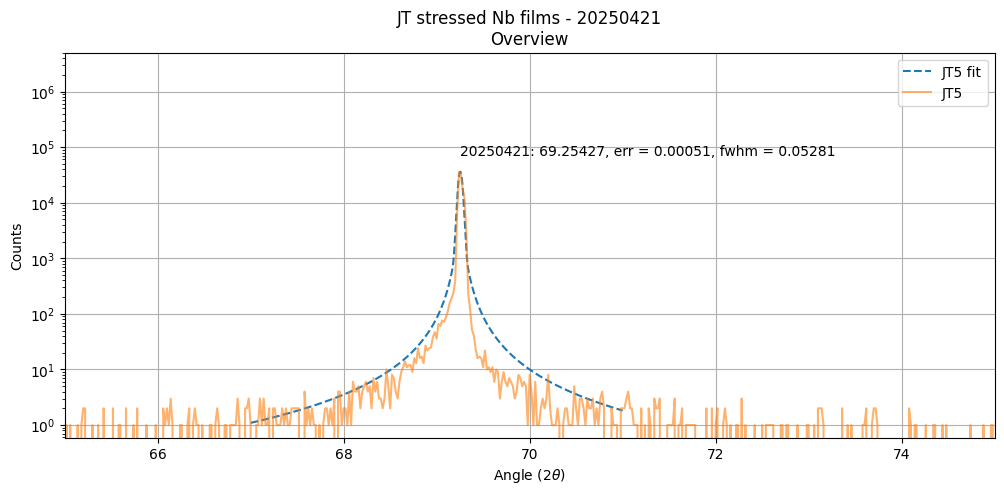

JT6 peak (20250421) center (x0): 68.99429, err = 0.00107, fwhm = 0.04160
[2.09838263e+03 6.89942911e+01 8.19093383e-03 2.72971464e-02
 7.80494228e-01]


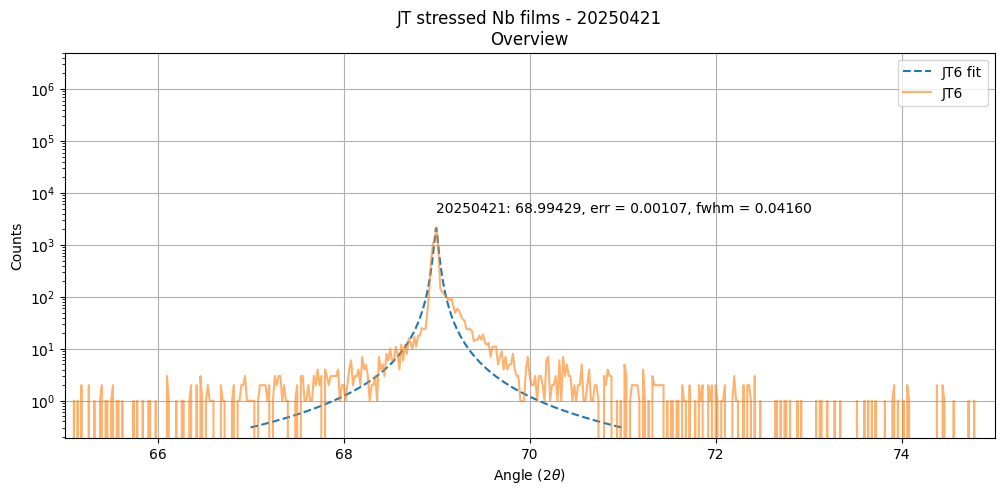

JT7 peak (20250421) center (x0): 69.18048, err = 0.00049, fwhm = 0.05161
[1.22424578e+05 6.91804846e+01 2.53122551e-02 2.98732440e-03
 1.51918603e-01]


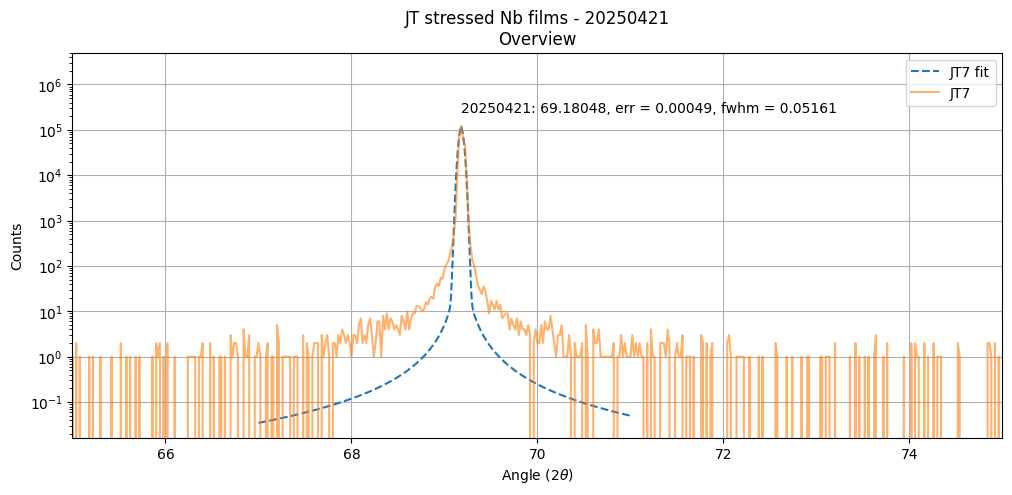

JT8 peak (20250421) center (x0): 69.17050, err = 0.00042, fwhm = 0.05241
[1.37529500e+05 6.91704965e+01 2.23255542e-02 2.77401774e-02
 9.63809436e-02]


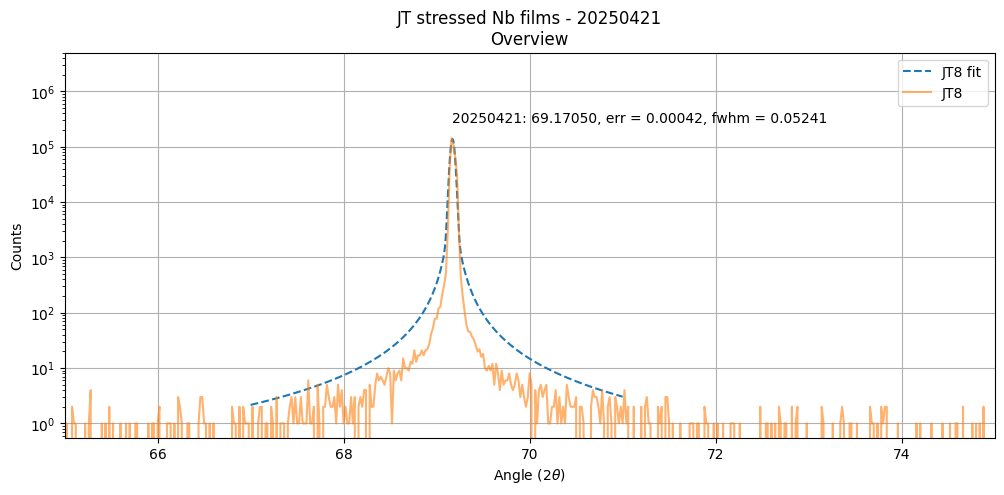

JT9 peak (20250421) center (x0): 69.22834, err = 0.00498, fwhm = 0.30043
[1.19531843e+02 6.92283371e+01 8.90457785e-05 1.91009789e-01
 6.51915446e-01]


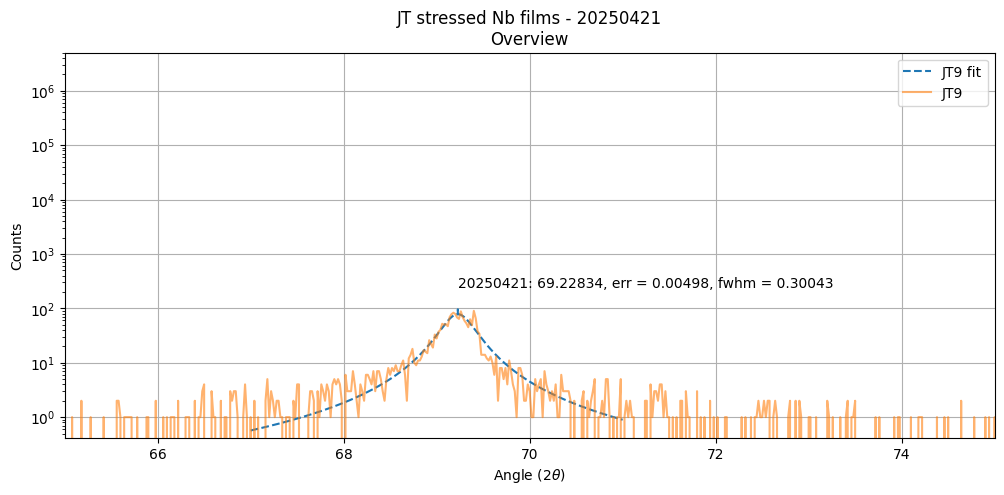

JT10 peak (20250421) center (x0): 69.28412, err = 0.00042, fwhm = 0.03440
[9.51706182e+03 6.92841195e+01 9.99110676e-05 2.25243614e-02
 6.84517131e-01]


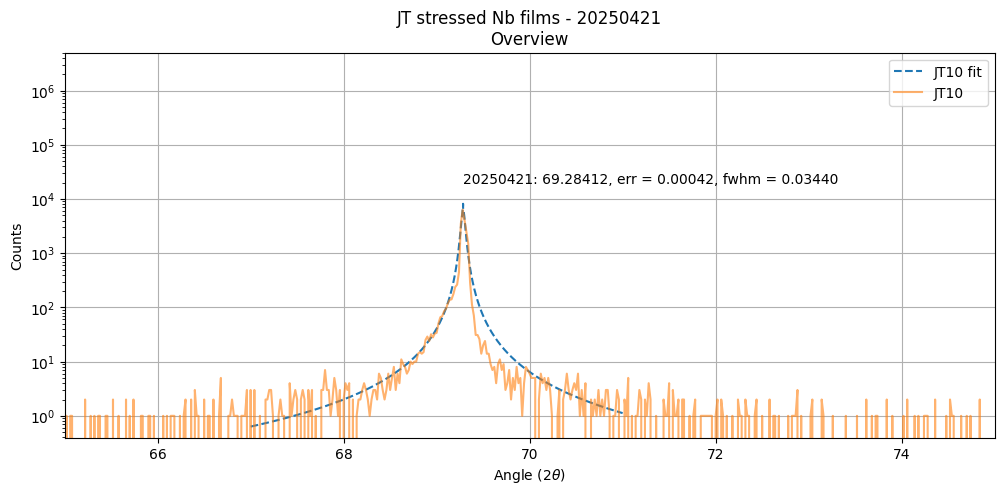

Si peaks statistics, mean: 69.20472789044511, std: 0.0808272418604588


In [125]:
#Error approx using Si reference peak (only Apr data had this peak)
def plot_fit_Si(filename, x_min=67.5, x_max=70.7, guess = [None, 69.15,0.001,0.005,0.5]):
    sample_name, x_data, y_data = read_xy_file(filename)
    
    # Select data around the peak
    x_data = np.array(x_data)
    y_data = np.array(y_data)
    mask = (x_data >= x_min) & (x_data <= x_max)
    x_fit = x_data[mask]
    y_fit = y_data[mask]

    # Initial guess and bounds
    p0 = [np.max(y_fit) if guess[0] == None else guess[0], guess[1], guess[2], guess[3], guess[4]]
    bounds = ([0, x_min, 0, 0, 0], [np.inf, x_max, 1, 1, 1])

    # Fit
    popt, pcov = curve_fit(pseudo_voigt, x_fit, y_fit, p0=p0, bounds=bounds)
    x_dense = np.linspace(x_fit.min(), x_fit.max(), 10000)
    fit_y = pseudo_voigt(x_dense, *popt)

    half_max = np.max(fit_y) / 2
    # find indices where curve crosses half max
    indices = np.where(fit_y >= half_max)[0]
    fwhm = x_dense[indices[-1]] - x_dense[indices[0]]
    
    perr = np.sqrt(np.diag(pcov))

    # Plot fit
    plt.plot(x_dense, fit_y, '--', label=f'{sample_name} fit')

    return popt, perr, fwhm  # [A, x0, sigma, gamma, eta]

date = "20250421"

guesses = [
    [1.68404863e+05, 6.91982605e+01, 2.25035533e-02, 1.78279031e-02, 2.74460235e-01], #JT1
    [1.13642119e+04, 6.92772786e+01, 1.92402814e-02, 3.48072817e-02, 2.21285289e-01], #JT2
    [1.74727772e+04, 6.92711586e+01, 1.81276024e-02, 3.33497159e-02, 2.42492513e-01], #JT3
    [1.52385208e+05, 6.91886181e+01, 1.77312276e-05, 1.70657498e-02, 9.29196703e-01], #JT4
    [3.57826118e+04, 6.92543157e+01, 2.21831760e-02, 4.11433421e-02, 8.85804903e-02], #JT5
    [2.02845588e+03, 6.89943178e+01, 8.64339533e-03, 2.72897650e-02, 8.09144009e-01], #JT6
    [1.22417291e+05, 6.91801136e+01, 5.43478141e-04, 3.10485546e-02, 6.29305594e-01], #JT7
    [1.37172184e+05, 6.91705293e+01, 2.23266295e-02, 2.94086611e-02, 8.56573177e-02], #JT8
    [1.19561041e+02, 6.92283370e+01, 8.90453046e-05, 1.91010151e-01, 6.51755666e-01], #JT9
    [9.51706182e+03, 6.92841259e+01, 9.99110676e-05, 2.25213820e-02, 6.84515819e-01], #JT10
    # [None, 69.25,0.0001,0.005,0.6] #JT10
]

peak_pos = []

for i in range(10):
    try:
        plt.figure(figsize=(12, 5))
        plt.title(f"JT stressed Nb films - {date}\nOverview")

        # if i == 3:
        #     popt, perr, fwhm = plot_fit_Si(f'JT{i+1}_Theta_2-Theta.xy', x_min=67.5, x_max=70.7, guess = [69.15,0.002,0.005,0.5])
        # elif i == 4:
        #     popt, perr, fwhm = plot_fit_Si(f'JT{i+1}_Theta_2-Theta.xy', x_min=67.5, x_max=70.7, guess = [69.25,0.005,0.005,0.5])
        # else:
        # popt, perr, fwhm = plot_fit_Si(f'JT{i+1}_Theta_2-Theta.xy', x_min=67, x_max=71, guess = [None, 69.2,0.001,0.005,0.5])
        popt, perr, fwhm = plot_fit_Si(f'JT{i+1}_Theta_2-Theta.xy', x_min=67, x_max=71, guess = guesses[i])
        plot_xy_data(f'JT{i+1}_Theta_2-Theta.xy')
        print(f"JT{i+1} peak (20250421) center (x0): {popt[1]:.5f}, err = {perr[1]:.5f}, fwhm = {fwhm:.5f}")
        plt.text(popt[1], popt[0]*2, f"20250421: {popt[1]:.5f}, err = {perr[1]:.5f}, fwhm = {fwhm:.5f}",rotation = 0)
        peak_pos.append(popt[1])
        print(popt)

        plt.xlabel(r'Angle (2$\theta$)')
        # plt.text(33.2, 320, r"$\beta$-Ta 002",rotation = 90)
        # plt.text(35.6, 30, r"$\beta$-Ta 410",rotation = 90)
        # plt.text(37.9, 2400, r"$\alpha$-Ta 110",rotation = 90)
        # plt.text(68.8, 95, r"Si 004",rotation = 90)
        # plt.text(70.2, 90, r"$\beta$-Ta 004",rotation = 90)
        # plt.text(81.6, 120, r"$\alpha$-Ta 220",rotation = 90)
        plt.ylabel('Counts')
        plt.yscale('log')
        plt.ylim(0,5000000)
        plt.xlim(65,75)
        plt.legend()
        plt.grid(True)
        # plt.savefig(f'XRD_data_JT{i+1}_re.png',format='png')
        plt.show()
    except:
        print(f"JT{i+1} fitting failed")

print("Si peaks statistics, mean: "+str(np.mean(peak_pos))+ ", std: " + str(np.std(peak_pos)))

[30.0, 30.02, 30.04, 30.06, 30.08, 30.1, 30.12, 30.14, 30.16, 30.18, 30.2, 30.22, 30.24, 30.26, 30.28, 30.3, 30.32, 30.34, 30.36, 30.38, 30.4, 30.42, 30.44, 30.46, 30.48, 30.5, 30.52, 30.54, 30.56, 30.58, 30.6, 30.62, 30.64, 30.66, 30.68, 30.7, 30.72, 30.74, 30.76, 30.78, 30.8, 30.82, 30.84, 30.86, 30.88, 30.9, 30.92, 30.94, 30.96, 30.98, 31.0, 31.02, 31.04, 31.06, 31.08, 31.1, 31.12, 31.14, 31.16, 31.18, 31.2, 31.22, 31.24, 31.26, 31.28, 31.3, 31.32, 31.34, 31.36, 31.38, 31.4, 31.42, 31.44, 31.46, 31.48, 31.5, 31.52, 31.54, 31.56, 31.58, 31.6, 31.62, 31.64, 31.66, 31.68, 31.7, 31.72, 31.74, 31.76, 31.78, 31.8, 31.82, 31.84, 31.86, 31.88, 31.9, 31.92, 31.94, 31.96, 31.98, 32.0, 32.02, 32.04, 32.06, 32.08, 32.1, 32.12, 32.14, 32.16, 32.18, 32.2, 32.22, 32.24, 32.26, 32.28, 32.3, 32.32, 32.34, 32.36, 32.38, 32.4, 32.42, 32.44, 32.46, 32.48, 32.5, 32.52, 32.54, 32.56, 32.58, 32.6, 32.62, 32.64, 32.66, 32.68, 32.7, 32.72, 32.74, 32.76, 32.78, 32.8, 32.82, 32.84, 32.86, 32.88, 32.9, 32.92, 

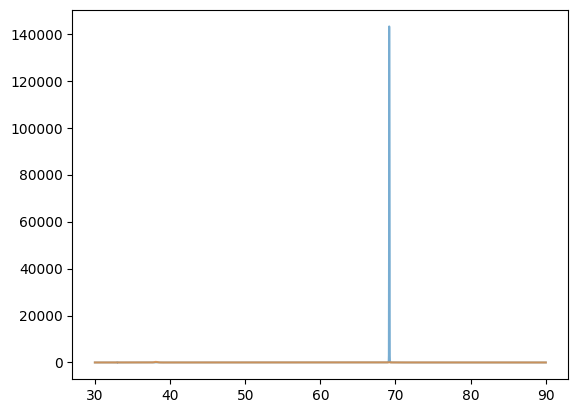

In [115]:
#plotting to check stuff for error approx (e.g. resolution steps)

# plot_xy_data(f'20250611_JT1_Theta_2-Theta.xy')
# plot_xy_data(f'20250611_JT2_Theta_2-Theta.xy')
# plot_xy_data(f'JT1_Theta_2-Theta.xy')
# plot_xy_data(f'JT2_Theta_2-Theta.xy')
# plot_xy_data(f'JT3_Theta_2-Theta.xy')
# plot_xy_data(f'JT4_Theta_2-Theta.xy')
# plot_xy_data(f'JT5_Theta_2-Theta.xy')
# plot_xy_data(f'JT6_Theta_2-Theta.xy')
# plot_xy_data(f'JT7_Theta_2-Theta.xy')
plot_xy_data(f'JT8_Theta_2-Theta.xy')
plot_xy_data(f'JT9_Theta_2-Theta.xy')
# plot_xy_data(f'JT10_Theta_2-Theta.xy')
sample_name, x_data, y_data = read_xy_file('JT2_Theta_2-Theta.xy')
print(x_data)
sample_name, x_data, y_data = read_xy_file('JT2_Theta_2-Theta.xy')
print(x_data)

## Other stuff from before

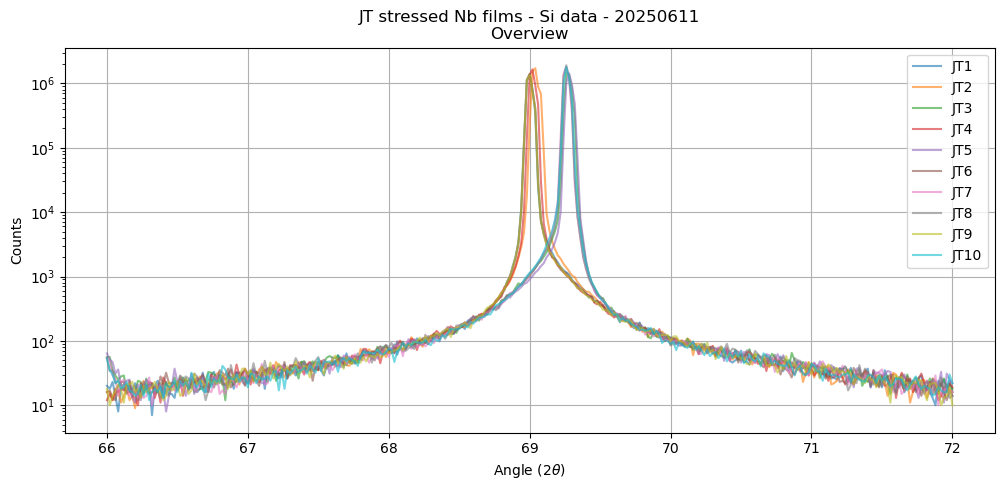

In [28]:
# Example usage
date = "20250611"

# for i in range(10):
plt.figure(figsize=(12, 5))
plt.title(f"JT stressed Nb films - Si data - {date}\nOverview")

for i in range(10):
    plot_xy_data(f'20250611_JT{i+1}Si_Theta_2-Theta.xy')
# popt = plot_fit_data(f'20250611_JT{i+1}Si_Theta_2-Theta.xy')
# print(f"JT{i+1} peak (20250611) center (x0): {popt[1]:.4f}")
# plt.text(popt[1], popt[0]*2, f"20250611: {popt[1]:.2f}",rotation = 0)

plt.xlabel(r'Angle (2$\theta$)')
# plt.text(33.2, 320, r"$\beta$-Ta 002",rotation = 90)
# plt.text(35.6, 30, r"$\beta$-Ta 410",rotation = 90)
# plt.text(37.9, 2400, r"$\alpha$-Ta 110",rotation = 90)
# plt.text(68.8, 95, r"Si 004",rotation = 90)
# plt.text(70.2, 90, r"$\beta$-Ta 004",rotation = 90)
# plt.text(81.6, 120, r"$\alpha$-Ta 220",rotation = 90)
plt.ylabel('Counts')
plt.yscale('log')
# plt.ylim(0,20000)
# plt.xlim(,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_JT{i+1}.png',format='png')
plt.show()



JT1 peak center (x0): 38.0358
JT2 peak center (x0): 38.2277
JT3 peak center (x0): 38.1362
JT4 peak center (x0): 38.4202


/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_42051/2307270448.py:36: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,5000)


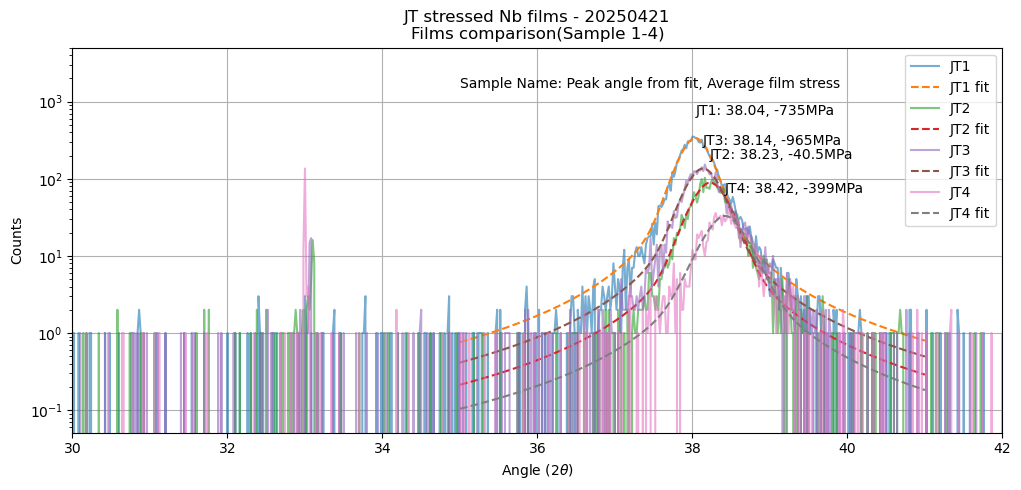

In [23]:
# Example usage
date = "20250421"

plt.figure(figsize=(12, 5))
plt.title(f"JT stressed Nb films - {date}\nFilms comparison(Sample 1-4)")
plt.text(35, 1500, "Sample Name: Peak angle from fit, Average film stress")

plot_xy_data('JT1_Theta_2-Theta.xy')
popt = plot_fit_data('JT1_Theta_2-Theta.xy')
print(f"JT1 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT1: {popt[1]:.2f}, -735MPa",rotation = 0)

plot_xy_data('JT2_Theta_2-Theta.xy')
popt = plot_fit_data('JT2_Theta_2-Theta.xy')
print(f"JT2 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT2: {popt[1]:.2f}, -40.5MPa",rotation = 0)

plot_xy_data('JT3_Theta_2-Theta.xy')
popt = plot_fit_data('JT3_Theta_2-Theta.xy')
print(f"JT3 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT3: {popt[1]:.2f}, -965MPa",rotation = 0)

plot_xy_data('JT4_Theta_2-Theta.xy')
popt = plot_fit_data('JT4_Theta_2-Theta.xy')
print(f"JT4 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT4: {popt[1]:.2f}, -399MPa",rotation = 0)
# plot_xy_data('JT5_Theta_2-Theta.xy')
# plot_xy_data('JT6_Theta_2-Theta.xy')
# plot_xy_data('JT7_Theta_2-Theta.xy')
# plot_xy_data('JT8_Theta_2-Theta.xy')
# plot_xy_data('JT9_Theta_2-Theta.xy')
# plot_xy_data('JT10_Theta_2-Theta.xy')
plt.xlabel(r'Angle (2$\theta$)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0,5000)
plt.xlim(30,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_JT{i+1}.png',format='png')
plt.show()



/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_56603/325247054.py:19: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,5000)


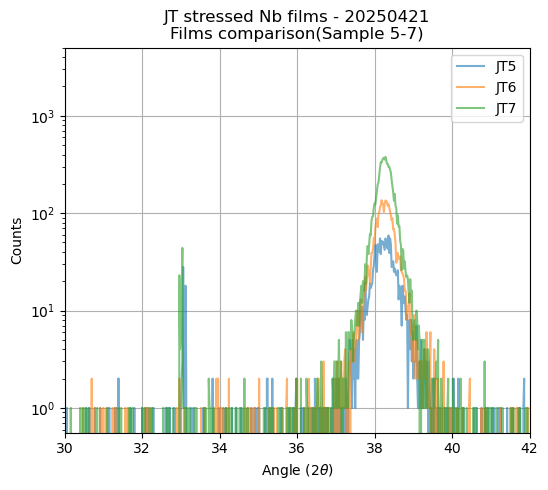

In [38]:
# Example usage
date = "20250421"

plt.figure(figsize=(6, 5))
plt.title(f"JT stressed Nb films - {date}\nFilms comparison(Sample 5-7)")
# plot_xy_data('JT1_Theta_2-Theta.xy')
# plot_xy_data('JT2_Theta_2-Theta.xy')
# plot_xy_data('JT3_Theta_2-Theta.xy')
# plot_xy_data('JT4_Theta_2-Theta.xy')
plot_xy_data('JT5_Theta_2-Theta.xy')
plot_xy_data('JT6_Theta_2-Theta.xy')
plot_xy_data('JT7_Theta_2-Theta.xy')
# plot_xy_data('JT8_Theta_2-Theta.xy')
# plot_xy_data('JT9_Theta_2-Theta.xy')
# plot_xy_data('JT10_Theta_2-Theta.xy')
plt.xlabel(r'Angle (2$\theta$)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0,5000)
plt.xlim(30,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_{date}.png',format='png')
plt.show()



/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_56603/2561363542.py:19: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,5000)


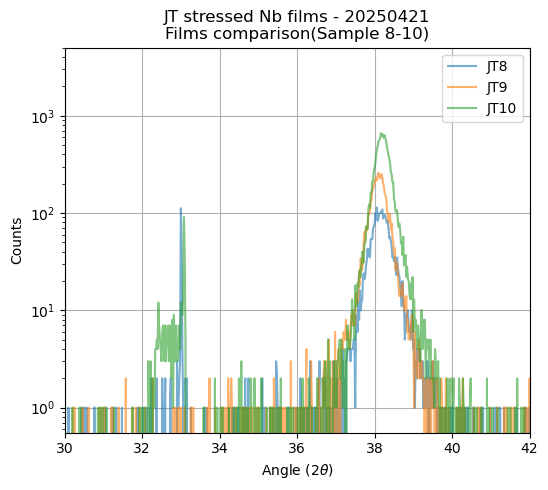

In [37]:
# Example usage
date = "20250421"

plt.figure(figsize=(6, 5))
plt.title(f"JT stressed Nb films - {date}\nFilms comparison(Sample 8-10)")
# plot_xy_data('JT1_Theta_2-Theta.xy')
# plot_xy_data('JT2_Theta_2-Theta.xy')
# plot_xy_data('JT3_Theta_2-Theta.xy')
# plot_xy_data('JT4_Theta_2-Theta.xy')
# plot_xy_data('JT5_Theta_2-Theta.xy')
# plot_xy_data('JT6_Theta_2-Theta.xy')
# plot_xy_data('JT7_Theta_2-Theta.xy')
plot_xy_data('JT8_Theta_2-Theta.xy')
plot_xy_data('JT9_Theta_2-Theta.xy')
plot_xy_data('JT10_Theta_2-Theta.xy')
plt.xlabel(r'Angle (2$\theta$)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0,5000)
plt.xlim(30,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_{date}.png',format='png')
plt.show()



JT5 peak center (x0): 38.2491
JT8 peak center (x0): 38.1627


/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_56603/791567001.py:28: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,5000)


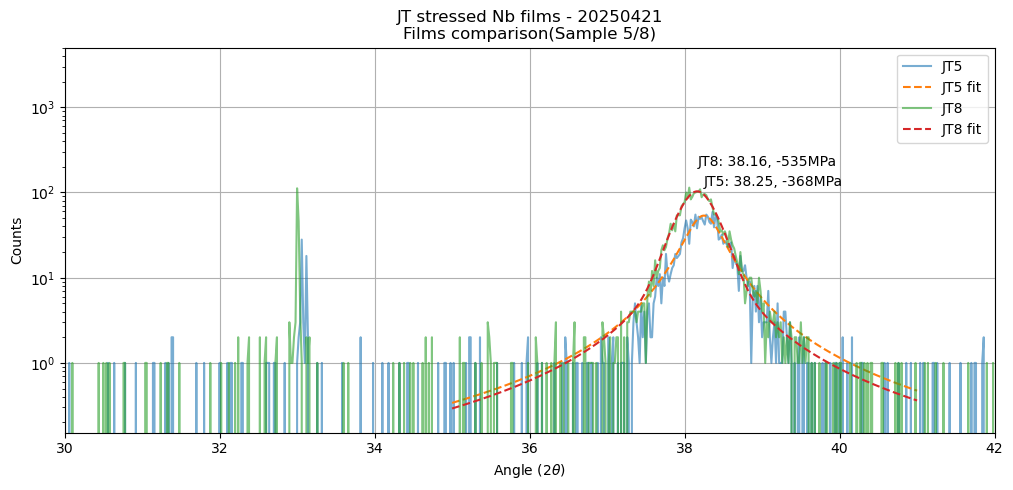

In [39]:
# Example usage
date = "20250421"

plt.figure(figsize=(12, 5))
plt.title(f"JT stressed Nb films - {date}\nFilms comparison(Sample 5/8)")
# plot_xy_data('JT1_Theta_2-Theta.xy')
# plot_xy_data('JT2_Theta_2-Theta.xy')
# plot_xy_data('JT3_Theta_2-Theta.xy')
# plot_xy_data('JT4_Theta_2-Theta.xy')
plot_xy_data('JT5_Theta_2-Theta.xy')
popt = plot_fit_data('JT5_Theta_2-Theta.xy')
print(f"JT5 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT5: {popt[1]:.2f}, -368MPa",rotation = 0)

# plot_xy_data('JT6_Theta_2-Theta.xy')
# plot_xy_data('JT7_Theta_2-Theta.xy')
plot_xy_data('JT8_Theta_2-Theta.xy')
popt = plot_fit_data('JT8_Theta_2-Theta.xy')
print(f"JT8 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT8: {popt[1]:.2f}, -535MPa",rotation = 0)


# plot_xy_data('JT9_Theta_2-Theta.xy')
# plot_xy_data('JT10_Theta_2-Theta.xy')
plt.xlabel(r'Angle (2$\theta$)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0,5000)
plt.xlim(30,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_{date}.png',format='png')
plt.show()



JT6 peak center (x0): 38.2610
JT9 peak center (x0): 38.1082


/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_56603/555474249.py:25: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,5000)


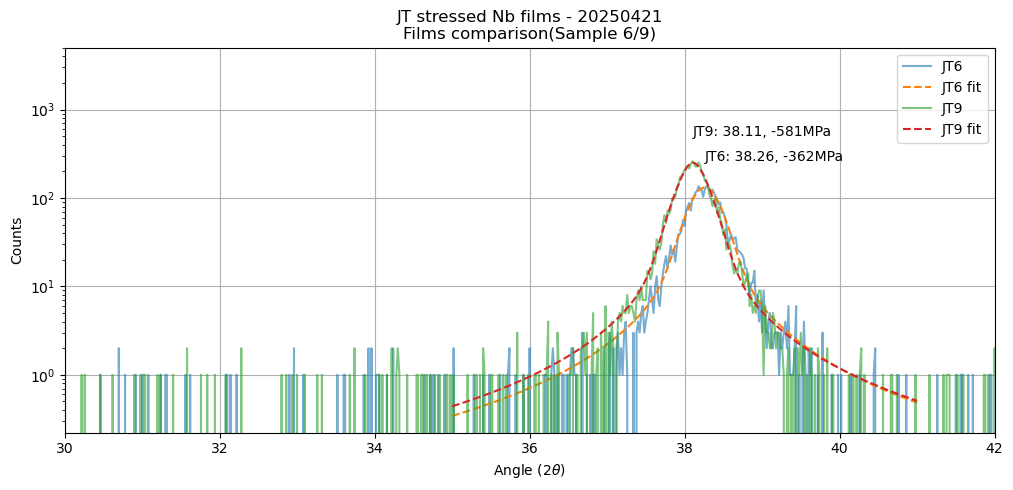

In [40]:
# Example usage
date = "20250421"

plt.figure(figsize=(12, 5))
plt.title(f"JT stressed Nb films - {date}\nFilms comparison(Sample 6/9)")
# plot_xy_data('JT1_Theta_2-Theta.xy')
# plot_xy_data('JT2_Theta_2-Theta.xy')
# plot_xy_data('JT3_Theta_2-Theta.xy')
# plot_xy_data('JT4_Theta_2-Theta.xy')
# plot_xy_data('JT5_Theta_2-Theta.xy')
plot_xy_data('JT6_Theta_2-Theta.xy')
popt = plot_fit_data('JT6_Theta_2-Theta.xy')
print(f"JT6 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT6: {popt[1]:.2f}, -362MPa",rotation = 0)
# plot_xy_data('JT7_Theta_2-Theta.xy')
# plot_xy_data('JT8_Theta_2-Theta.xy')
plot_xy_data('JT9_Theta_2-Theta.xy')
popt = plot_fit_data('JT9_Theta_2-Theta.xy')
print(f"JT9 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT9: {popt[1]:.2f}, -581MPa",rotation = 0)
# plot_xy_data('JT10_Theta_2-Theta.xy')
plt.xlabel(r'Angle (2$\theta$)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0,5000)
plt.xlim(30,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_{date}.png',format='png')
plt.show()



JT7 peak center (x0): 38.2657
JT10 peak center (x0): 38.2022


/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_56603/2055381952.py:26: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,5000)


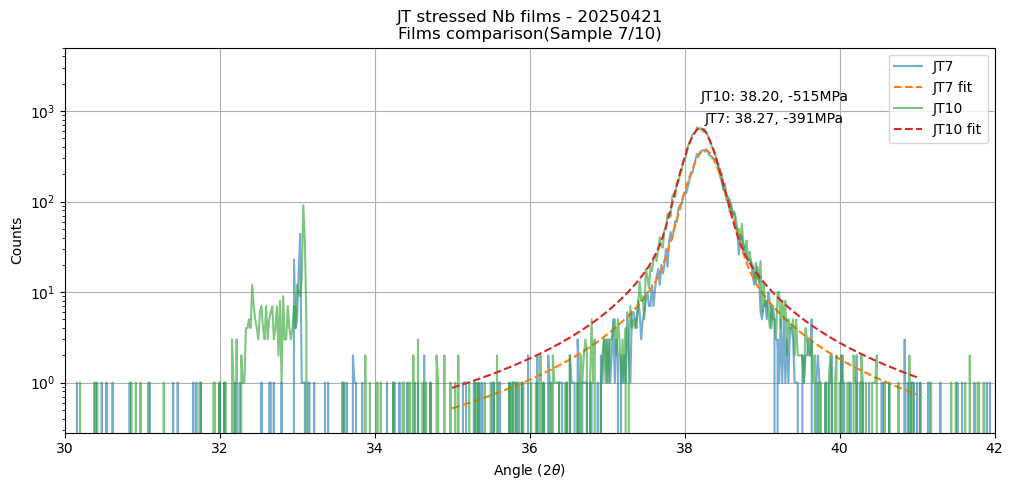

In [41]:
# Example usage
date = "20250421"

plt.figure(figsize=(12, 5))
plt.title(f"JT stressed Nb films - {date}\nFilms comparison(Sample 7/10)")
# plot_xy_data('JT1_Theta_2-Theta.xy')
# plot_xy_data('JT2_Theta_2-Theta.xy')
# plot_xy_data('JT3_Theta_2-Theta.xy')
# plot_xy_data('JT4_Theta_2-Theta.xy')
# plot_xy_data('JT5_Theta_2-Theta.xy')
# plot_xy_data('JT6_Theta_2-Theta.xy')
plot_xy_data('JT7_Theta_2-Theta.xy')
popt = plot_fit_data('JT7_Theta_2-Theta.xy')
print(f"JT7 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT7: {popt[1]:.2f}, -391MPa",rotation = 0)

# plot_xy_data('JT8_Theta_2-Theta.xy')
# plot_xy_data('JT9_Theta_2-Theta.xy')
plot_xy_data('JT10_Theta_2-Theta.xy')
popt = plot_fit_data('JT10_Theta_2-Theta.xy')
print(f"JT10 peak center (x0): {popt[1]:.4f}")
plt.text(popt[1], popt[0]*2, f"JT10: {popt[1]:.2f}, -515MPa",rotation = 0)
plt.xlabel(r'Angle (2$\theta$)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0,5000)
plt.xlim(30,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_{date}.png',format='png')
plt.show()



/var/folders/gl/m1qd0tfj7zn_brj91bzzf3cr0000gn/T/ipykernel_56603/765714064.py:21: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  plt.ylim(0,5000)


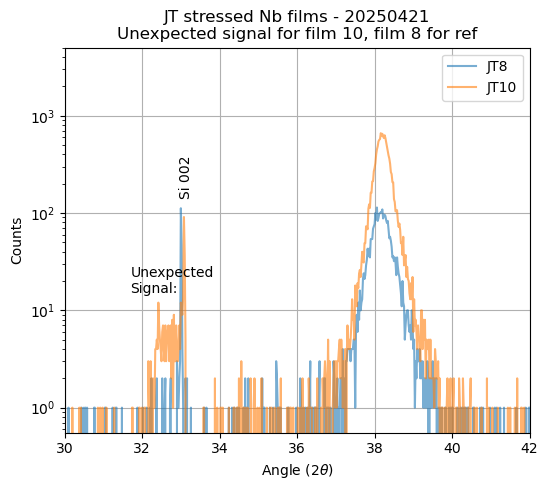

In [42]:
# Example usage
date = "20250421"

plt.figure(figsize=(6, 5))
plt.title(f"JT stressed Nb films - {date}\nUnexpected signal for film 10, film 8 for ref")
# plot_xy_data('JT1_Theta_2-Theta.xy')
# plot_xy_data('JT2_Theta_2-Theta.xy')
# plot_xy_data('JT3_Theta_2-Theta.xy')
# plot_xy_data('JT4_Theta_2-Theta.xy')
# plot_xy_data('JT5_Theta_2-Theta.xy')
# plot_xy_data('JT6_Theta_2-Theta.xy')
# plot_xy_data('JT7_Theta_2-Theta.xy')
plot_xy_data('JT8_Theta_2-Theta.xy')
# plot_xy_data('JT9_Theta_2-Theta.xy')
plot_xy_data('JT10_Theta_2-Theta.xy')
plt.xlabel(r'Angle (2$\theta$)')
plt.text(32.95, 150, r"Si 002",rotation = 90)
plt.text(31.7, 15, "Unexpected\nSignal:")
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0,5000)
plt.xlim(30,42)
plt.legend()
plt.grid(True)
plt.savefig(f'XRD_data_{date}.png',format='png')
plt.show()

